In [1]:
import numpy as np
scene_path = '/home/ubuntu/TJH/Work/aff_ws/SGS-SLAM/experiments/Replica/room0_0/params.npz'
all_params = dict(np.load(scene_path, allow_pickle=True))
print(all_params.keys())


dict_keys(['means3D', 'rgb_colors', 'unnorm_rotations', 'logit_opacities', 'log_scales', 'semantic_ids', 'semantic_colors', 'cam_unnorm_rots', 'cam_trans', 'timestep', 'intrinsics', 'w2c', 'org_width', 'org_height', 'gt_w2c_all_frames', 'keyframe_time_indices'])


In [4]:
import torch.nn.functional as F
import torch
def build_rotation(q, device="cuda"):
    norm = torch.sqrt(q[:, 0] * q[:, 0] + q[:, 1] * q[:, 1] + q[:, 2] * q[:, 2] + q[:, 3] * q[:, 3])
    q = q / norm[:, None]
    rot = torch.zeros((q.size(0), 3, 3), device=device)
    r = q[:, 0]
    x = q[:, 1]
    y = q[:, 2]
    z = q[:, 3]
    rot[:, 0, 0] = 1 - 2 * (y * y + z * z)
    rot[:, 0, 1] = 2 * (x * y - r * z)
    rot[:, 0, 2] = 2 * (x * z + r * y)
    rot[:, 1, 0] = 2 * (x * y + r * z)
    rot[:, 1, 1] = 1 - 2 * (x * x + z * z)
    rot[:, 1, 2] = 2 * (y * z - r * x)
    rot[:, 2, 0] = 2 * (x * z - r * y)
    rot[:, 2, 1] = 2 * (y * z + r * x)
    rot[:, 2, 2] = 1 - 2 * (x * x + y * y)
    return rot
for k in all_params.keys():
    if k == 'semantic_id':
        all_params[k] = torch.tensor(all_params[k]).cuda().int() # semantic_id has dtype int
    else:
        all_params[k] = torch.tensor(all_params[k]).cuda().float()
all_w2cs = []
num_t = all_params['cam_unnorm_rots'].shape[-1]
for t_i in range(num_t):
    cam_rot = F.normalize(all_params['cam_unnorm_rots'][..., t_i])
    cam_tran = all_params['cam_trans'][..., t_i]
    rel_w2c = torch.eye(4).cuda().float()
    rel_w2c[:3, :3] = build_rotation(cam_rot)
    rel_w2c[:3, 3] = cam_tran
    all_w2cs.append(rel_w2c.cpu().numpy())
print(all_w2cs[0])

/tmp/ipykernel_764973/1955030833.py:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  all_params[k] = torch.tensor(all_params[k]).cuda().float()


[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


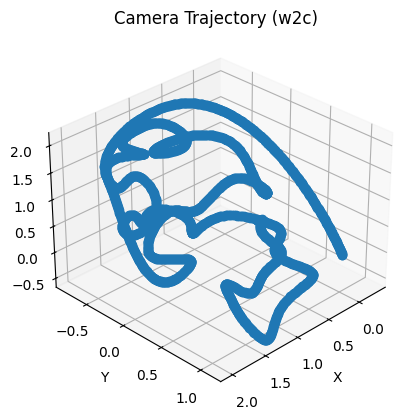

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 不可删除，否则三维显示出问题

# 假设 all_w2cs 是一个 list，包含 T 个 (4, 4) 的 numpy 数组
# 我们需要将每一帧的相机位置（world 坐标系下）提取出来

cam_positions = []

for w2c in all_w2cs:
    w2c = np.array(w2c)
    # 相机中心在世界坐标系下的位置是 w2c 的逆矩阵作用于原点
    c2w = np.linalg.inv(w2c)
    cam_pos = c2w[:3, 3]  # 相机位置（世界坐标系下）
    cam_positions.append(cam_pos)

cam_positions = np.stack(cam_positions, axis=0)

# 可视化轨迹
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(cam_positions[:, 0], cam_positions[:, 1], cam_positions[:, 2], marker='o')

ax.set_title("Camera Trajectory (w2c)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.view_init(elev=30, azim=45)  # 你可以根据需要调整视角
plt.show()
